# SVM Lineari con Embeddings

In [1]:
# Import dei moduli
import sqlite3
import re
import numpy as np 
import utils_svm
import os

from loguru import logger
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier

### Estrazione, salvataggio e lettura degli embeddings

In [2]:
sql_path = 'embeddings/ukwac128.sqlite'
embeddings_path = 'embeddings/ukwak128.txt'

In [3]:
con = sqlite3.connect(sql_path)

In [4]:
cur = con.cursor()

In [5]:
# Leggiamo il file degli embeddings e lo ritorniamo come file txt
'''with open(embeddings_path, 'w+', encoding='UTF-8') as out_file:
    for embedding in cur.execute("SELECT * FROM store"):
        str_embedding = [str(el) for el in embedding[:-1]]
        out_file.write('\t'.join(str_embedding)+'\n')

out_file.close()'''

'with open(embeddings_path, \'w+\', encoding=\'UTF-8\') as out_file:\n    for embedding in cur.execute("SELECT * FROM store"):\n        str_embedding = [str(el) for el in embedding[:-1]]\n        out_file.write(\'\t\'.join(str_embedding)+\'\n\')\n\nout_file.close()'

In [6]:
# Funzione per la lettura dei  word embeddings
def load_word_embeddings(src_path):
    '''
    Funzione che legge il file .txt contenente gli embeddings, ne trasforma ogni componente in float type e lo salva in un dizionario.
    
    :param src_path: la path del file .txt che contiene gli embeddings
    :returns embeddings: il dizionario contente gli embeddings

    '''
    embeddings = dict()
    for line in open(src_path, 'r', encoding='UTF-8'):
        line = line.strip().split('\t')
        word = line[0]
        embedding = line[1:]
        embedding = [float(comp) for comp in embedding]
        embeddings[word] = np.asarray(embedding)
    
    return embeddings

In [7]:
embeddings = load_word_embeddings(embeddings_path)

### Definizione delle classi per la lettura del dizionario e l'assegnazione delle features

In [8]:
class Token:

    def __init__(self, word, pos):
        self.word = word
        self.pos = pos

    def __str__(self):
        return f'Word = {self.word}, POS = {self.pos}'

In [9]:
class Document: 

    def __init__(self, document_path, dataset):

        self.document_path = document_path
        self.doc_id = None
        self.split = None
        self.author = None
        self.text = None
        self._load_doc_info(document_path, dataset)
        self.tokens = []
        self.features = None

    def _load_doc_info(self, document_path, dataset):
        self.doc_id = document_path.split('/')[-1].split('.')[0]
        self.split = dataset[self.doc_id]['split']
        self.author = dataset[self.doc_id]['author']
        self.text = dataset[self.doc_id]['text']
    
    def __str__(self):
        return ' '.join({token.word for token in self.tokens})


### Estrazione dei Token ed Associazione con Embeddings

In [10]:
conllu = 'Profiling_UD/16152'
dictionary = 'data.json'

In [11]:
# Caricamento del dizionario con gli autori
data = utils_svm.load_data(dictionary)

In [12]:
# Salvataggio di ogni file_path per document in formato .conllu contenente le annotazioni dei testi
all_documents_path = []
for file_name in os.listdir(conllu):
    file_path = os.path.join(conllu, file_name)
    all_documents_path.append(file_path)

In [ ]:
def get_digits(text):
    
    '''
    Funzione che prova a convertire una stringa in un numero intero o normalizza il testo in base al contenuto numerico. Se la stringa può essere convertita 
    in un intero e il valore è compreso tra 0 e 2099, restituisce la stringa del numero. Se il numero è maggiore o uguale a 2100, restituisce una stringa 
    che indica la lunghezza del numero ('DIGLEN_<lunghezza>'). Se la conversione fallisce, sostituisce ogni cifra numerica nella stringa con '@Dg'
    e restituisce il risultato.

    :param text: La stringa da elaborare
    :return str: Una rappresentazione numerica normalizzata o una stringa modificata in caso di errore.
    
    '''
    try:
        val = int(text)
    except:
        text = re.sub(r'\d', '@Dg', text)
        return text
    if val >= 0 and val < 2100:
        return str(val)
    else:
        return 'DIGLEN_'+str(len(str(val)))

In [ ]:
def normalize_text(word):
    
    '''
    Funzione che prende in input una parola e la normalizza identificandola come URL se contiene la stringa http, se presenta una lunghezza maggiore di 26 la
    etichetta come __LONG-LONG__, ci invoca la funzione get_digits e se il risultato di questa funzione è diverso dalla parola originale, questa è segnata come
    la nuova parola trovata. Inoltre, se il primo carattere della parole è in maiuscolo, rende maiuscola tutta la parola, altrimenti la rende minuscola.

    :param word: la parola da analizzare
    :return word: la parola normalizzata
    
    '''
    if 'http' in word or ('.' in word and '\\' in word):
        word = str("___URL___")
        return word
    
    if len(word)>26:
        return "__LONG-LONG__"
    new_word = get_digits(word)
    
    if new_word != word:
        word = new_word
    
    if word[0].isupper():
        word = word.capitalize()
    
    else:
        word = word.lower()

    return word

In [15]:
# Funzione per l'estrazione dei tokens da ogni file
def get_tokens_from_file(src_path):

    """
    Funzione che estrae i token da un file CoNLL-U, gestendo anche i casi di token multiword (con ID del tipo 1-2), 
    normalizzando il testo e associando la POS.

    :args src_path: percorso del file da cui estrarre i token (formato CoNLL-U)

    :returns document_tokens: lista di oggetti Token estratti dal file, con attributi word e pos
    """

    document_tokens = []
    lines_to_skip = 0
    take_pos = False
    for line in open(src_path, 'r', encoding='UTF-8'):

        if line[0].isdigit():
            splitted_line = line.strip().split('\t')
            
            if '-' in splitted_line[0]:

                skip_ids = splitted_line[0].split('-')

                lines_to_skip = int(skip_ids[1]) - int(skip_ids[0]) + 1 
                take_pos = True
                word = normalize_text(splitted_line[1])
                pos = splitted_line[3]
                token = Token(word=word, pos=None) 

                document_tokens.append(token)
            
            else:
                
                if lines_to_skip == 0:   
                    word = normalize_text(splitted_line[1])
                    pos = splitted_line[3]
                    token = Token(word=word, pos=pos)

                    document_tokens.append(token)
                
                if take_pos:
                    pos = splitted_line[3]
                    document_tokens[-1].pos = pos
                    take_pos = False
                
                lines_to_skip = max(0, lines_to_skip-1)

    return document_tokens

In [18]:
# Definizione della lista con tutti i documenti
all_documents = []

for file_name in os.listdir(conllu):
    file_path = os.path.join(conllu, file_name)

    document = Document(file_path, data)
    document_tokens = get_tokens_from_file(file_path)
    document.tokens = document_tokens
    all_documents.append(document)

### Estrazione delle features

In [ ]:
# Definizione della dimensione degli embeddings: sono stati scaricati di dimensione 128 dunque inseriamo questa
embeddings_dim = 128

In [20]:
# Funzioni per l'aggregazione degli embeddings secondo diverse strategie: media, somma e massimo
def compute_embeddings_mean(document_embeddings):
    sum_array = np.sum(document_embeddings, axis=0)
    mean_array = np.divide(sum_array, len(document_embeddings))
    if not np.all(np.isfinite(mean_array)):
        print("Warning: NaN or inf in mean embedding")
    return mean_array

def compute_embeddings_sum(document_embeddings):
    sum_array = np.sum(document_embeddings, axis=0)
    if not np.all(np.isfinite(sum_array)):
        print('Warning: NaN or inf in sum embedding')
    return sum_array

def compute_embeddings_max(document_embeddings):
    max_array = np.max(document_embeddings, axis = 0)
    if not np.all(np.isfinite(max_array)):
        print('Warning: NaN or inf in max_array')
    return max_array

In [ ]:
# Funzioni per il calcolo dell'aggregazione di ogni parola nel testo
def compute_all_embeddings_mean(documents):

    for document in documents:
        # Inizializza lista vuota di embeddings per ogni documento
        document_embeddings = []
        # Per ogni token individua la parola ed il pos e ne prende l'embedding
        for token in document.tokens:
            word = token.word
            if word in embeddings:
                document_embeddings.append(embeddings[word])
        if len(document_embeddings) == 0:
            mean_document_embeddings = np.zeros(embeddings_dim)
        else:
            mean_document_embeddings = compute_embeddings_mean(document_embeddings)
        document.features = mean_document_embeddings


def compute_all_embeddings_sum(documents):

    for document in documents:
        document_embeddings = []
        for token in document.tokens:
            word = token.word
            if word in embeddings:
                document_embeddings.append(embeddings[word])
    
        if len(document_embeddings) == 0:
            sum_document_embeddings = np.zeros(embeddings_dim)
        else:
            sum_document_embeddings = compute_embeddings_sum(document_embeddings)
        document.features = sum_document_embeddings


def compute_all_embeddings_max(documents):

    for document in documents:
        document_embeddings = []
        for token in document.tokens:
            word = token.word
            if word in embeddings:
                document_embeddings.append(embeddings[word])
    
        if len(document_embeddings) == 0:
            max_document_embeddings = np.zeros(embeddings_dim)
        else:
            max_document_embeddings = compute_embeddings_max(document_embeddings)
        document.features = max_document_embeddings

In [22]:
# Funzione che calcola l'aggregazione degli embeddings sulla base del metodo scelto e utilizzando le POS
def compute_filtered_embeddings_agg(documents, code, pos_list):
    
    """
    Funzione che itera su una lista di documenti,filtra i token in base alla parte del discorso (POS) specificata in `pos_list` e verifica se esiste 
    un embedding corrispondente per ciascuna parola nella struttura `embeddings`. Gli embeddings validi 
    vengono accumulati in una lista `document_embeddings`. A seconda del valore di `code`, viene applicato 
    un metodo di aggregazione (media, somma o massimo) sugli embeddings raccolti. Se nessun embedding è valido, 
    viene assegnato un vettore di zeri. Il risultato dell’aggregazione viene assegnato all’attributo `features` 
    del documento.

    :param documents: lista di documenti, ciascuno composto da una lista di token con attributi 'word' e 'pos'
    :param embeddings: dizionario contenente gli embeddings per le parole
    :param embeddings_dim: dimensione dei vettori di embedding
    :param pos_list: lista di parti del discorso (POS) da considerare (es. ['ADJ', 'NOUN', 'VERB'])
    :param code: intero che specifica il metodo di aggregazione da applicare:
             1 = media, 2 = somma, 3 = massimo
    """
    # Scorre i documenti in all_documents
    for document in documents:

        # Inizializza lista vuota di embeddings per ogni documento
        document_embeddings = []
        
        # Per ogni token individua la parola ed il pos e ne prende l'embedding
        for token in document.tokens:
            word = token.word
            pos = token.pos
            if word in embeddings and pos in pos_list:
                document_embeddings.append(embeddings[word])

        # Se il codice inserito è uno, il metodo di aggregazione scelto è la media
        if code == 1:
            if len(document_embeddings) == 0:
                mean_document_embeddings = np.zeros(embeddings_dim)
            else:
                mean_document_embeddings = compute_embeddings_mean(document_embeddings)
            document.features = mean_document_embeddings
    
        # Se il codice inserito è due, il metodo di aggregazione scelto è la somma
        elif code == 2:
            if len(document_embeddings) == 0:
                sum_document_embeddings = np.zeros(embeddings_dim)
            else:
                sum_document_embeddings = compute_embeddings_sum(document_embeddings)
            document.features = sum_document_embeddings
        
        # Se il codice inserito è tre, il metodo di aggregazione scelto è il massimo
        elif code ==3:
            if len(document_embeddings) == 0:
                max_document_embeddings = np.zeros(embeddings_dim)
            else:
                max_document_embeddings = compute_embeddings_max(document_embeddings)
            document.features = max_document_embeddings
        
        # Se si sceglie un numero non valido per il codice si visualizza l'errore
        else:
            logger.error('Codice non valido')


In [23]:
# Funzione per la divisione in training, validation e test set
def split(all_documents):
    
    train_features, train_labels = [], []
    val_features, val_labels = [], []
    test_features, test_labels = [], []

    for document in all_documents:
        if document.split == 'train':
            train_features.append(document.features)
            train_labels.append(document.author)

        elif document.split == 'val':
            val_features.append(document.features)
            val_labels.append(document.author)

        elif document.split == 'test':
            test_features.append(document.features)
            test_labels.append(document.author)
    
    return train_features, train_labels, val_features, val_labels, test_features, test_labels

In [ ]:
# Funzione per l'automatizzazione delle fasi di training e validation della task n° 3

def validation_task_3(all_docs):

    # Divisione dei documenti in train, validation and test set
    train_features, train_labels, val_features, val_labels, test_features, test_labels = split(all_docs)

    # Scaling delle Features
    scaler = MinMaxScaler()

    x_train = scaler.fit_transform(train_features)
    y_train = np.array(train_labels)

    x_val = scaler.transform(val_features)
    y_val = np.array(val_labels)

    x_test = scaler.transform(test_features)
    y_test = np.array(test_labels)
    
    print("Train has NaNs:", np.isnan(x_train).any())
    print("Train has Infs:", np.isinf(x_train).any())
    print("Train max value:", np.max(x_train))
    print("Train min value:", np.min(x_train))

    # Model Selection
    grid_results = utils_svm.model_selection(x_train, y_train)
    model = LinearSVC(**grid_results.best_params_)
    model.fit(x_train, y_train)

    # Assessment sul set di validazione
    utils_svm.predict(model, x_val, y_val, split = 'validation set')

    dummy_clf = DummyClassifier(strategy="uniform")
    dummy_clf.fit(x_train, y_train)
    print(f"Accuracy del DummyClassifier: {dummy_clf.score(x_val, y_val)}")

    return x_test, y_test, model

## Estrazione e controllo performance per aggregazioni diverse

## Aggregazione per tutte le parole

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear fa

0.8697222222222223
Accuracy sul validation set: 0.7113333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.61      0.65      0.63       500
       Eliot       0.72      0.63      0.67       500
        Hugo       0.81      0.86      0.83       500

    accuracy                           0.71      1500
   macro avg       0.71      0.71      0.71      1500
weighted avg       0.71      0.71      0.71      1500

Accuracy del DummyClassifier: 0.3466666666666667


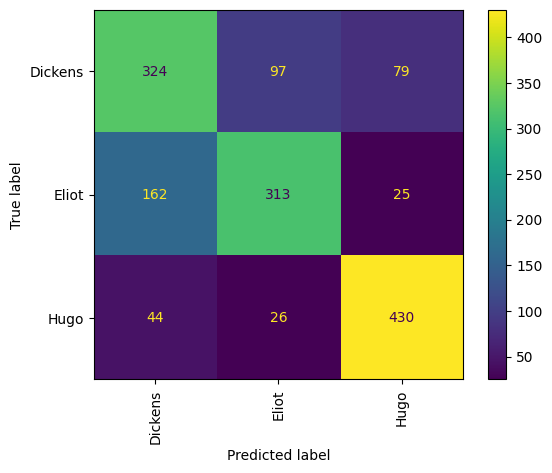

In [28]:
# Cominciamo con la media 
compute_all_embeddings_mean(all_documents)
x_test_mean_tot, y_test_mean_tot, model_mean_tot = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear fa

0.8672222222222222
Accuracy sul validation set: 0.7086666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.61      0.67      0.64       500
       Eliot       0.72      0.63      0.67       500
        Hugo       0.81      0.83      0.82       500

    accuracy                           0.71      1500
   macro avg       0.71      0.71      0.71      1500
weighted avg       0.71      0.71      0.71      1500

Accuracy del DummyClassifier: 0.3333333333333333


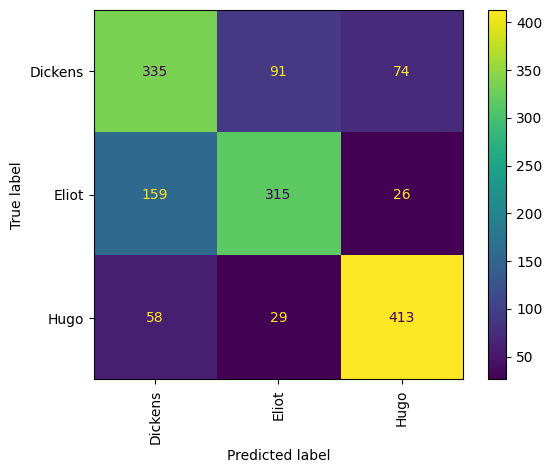

In [29]:
# Somma
compute_all_embeddings_sum(all_documents)
x_test_sum_tot, y_test_sum_tot, model_sum_tot = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.7388888888888889
Accuracy sul validation set: 0.6446666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.58      0.62      0.60       500
       Eliot       0.67      0.57      0.62       500
        Hugo       0.69      0.74      0.71       500

    accuracy                           0.64      1500
   macro avg       0.65      0.64      0.64      1500
weighted avg       0.65      0.64      0.64      1500

Accuracy del DummyClassifier: 0.3506666666666667


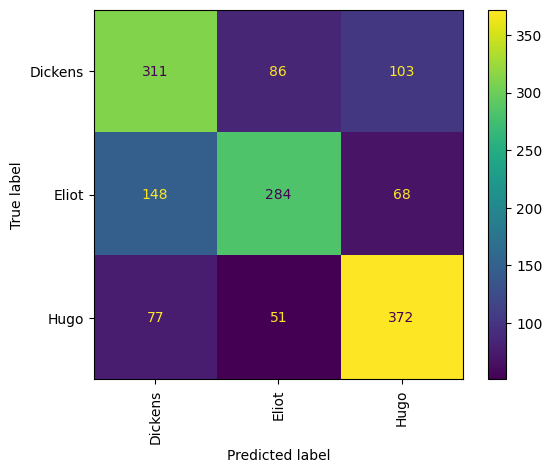

In [69]:
# Massimo
compute_all_embeddings_max(all_documents)
x_test_max_tot, y_test_max_tot, model_max_tot = validation_task_3(all_documents)

### 1) ADJ, NOUN e VERB

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6802777777777779
Accuracy sul validation set: 0.5993333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.49      0.43      0.45       500
       Eliot       0.58      0.50      0.54       500
        Hugo       0.69      0.87      0.77       500

    accuracy                           0.60      1500
   macro avg       0.59      0.60      0.59      1500
weighted avg       0.59      0.60      0.59      1500

Accuracy del DummyClassifier: 0.30666666666666664


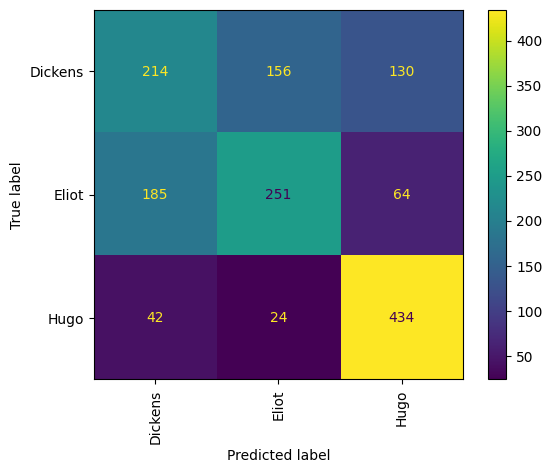

In [65]:
# Media
compute_filtered_embeddings_agg(all_documents, 1, pos_list = ['ADJ', 'NOUN', 'VERB'])
x_test_1, y_test_1, model_1 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6875
Accuracy sul validation set: 0.5966666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.48      0.44      0.46       500
       Eliot       0.58      0.49      0.53       500
        Hugo       0.70      0.86      0.77       500

    accuracy                           0.60      1500
   macro avg       0.58      0.60      0.59      1500
weighted avg       0.58      0.60      0.59      1500

Accuracy del DummyClassifier: 0.344


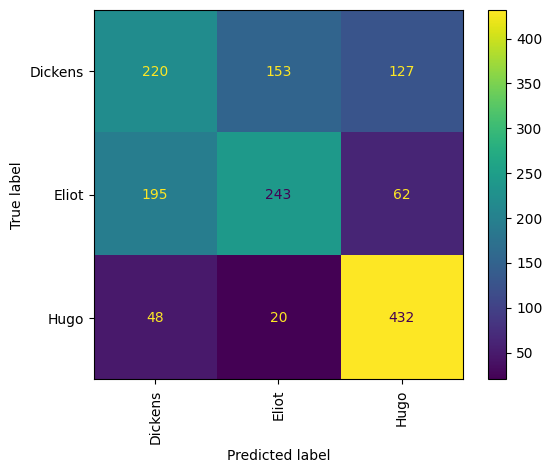

In [ ]:
# Somma
compute_filtered_embeddings_agg(all_documents, 2, pos_list = ['ADJ', 'NOUN', 'VERB'])
x_test_2, y_test_2, model_2 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6180555555555556
Accuracy sul validation set: 0.556
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.45      0.38      0.41       500
       Eliot       0.52      0.43      0.47       500
        Hugo       0.64      0.86      0.73       500

    accuracy                           0.56      1500
   macro avg       0.54      0.56      0.54      1500
weighted avg       0.54      0.56      0.54      1500

Accuracy del DummyClassifier: 0.33466666666666667


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


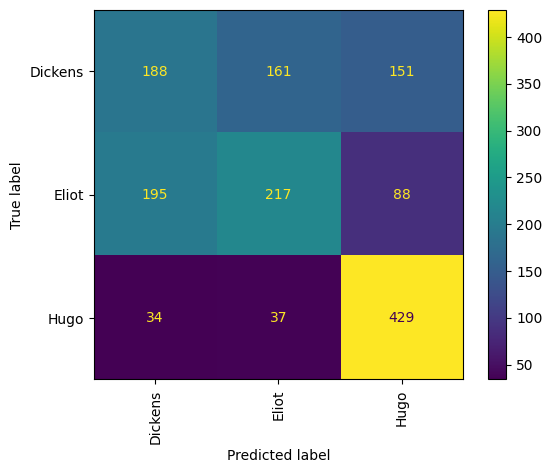

In [ ]:
# Max
compute_filtered_embeddings_agg(all_documents, 3, pos_list = ['ADJ', 'NOUN', 'VERB'])
x_test_3, y_test_3, model_3 = validation_task_3(all_documents)

### 2) VERB, NOUN e ADV

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6727777777777777
Accuracy sul validation set: 0.5906666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.48      0.44      0.46       500
       Eliot       0.57      0.47      0.52       500
        Hugo       0.68      0.87      0.76       500

    accuracy                           0.59      1500
   macro avg       0.58      0.59      0.58      1500
weighted avg       0.58      0.59      0.58      1500

Accuracy del DummyClassifier: 0.342


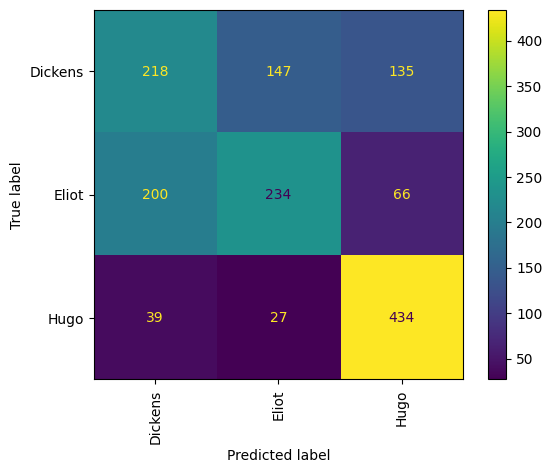

In [ ]:
# Media
compute_filtered_embeddings_agg(all_documents, 1, pos_list = ['VERB', 'NOUN', 'ADV'])
x_test_4, y_test_4, model_4 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6813888888888889
Accuracy sul validation set: 0.5753333333333334
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.46      0.47      0.47       500
       Eliot       0.56      0.46      0.50       500
        Hugo       0.69      0.80      0.74       500

    accuracy                           0.58      1500
   macro avg       0.57      0.58      0.57      1500
weighted avg       0.57      0.58      0.57      1500

Accuracy del DummyClassifier: 0.3406666666666667


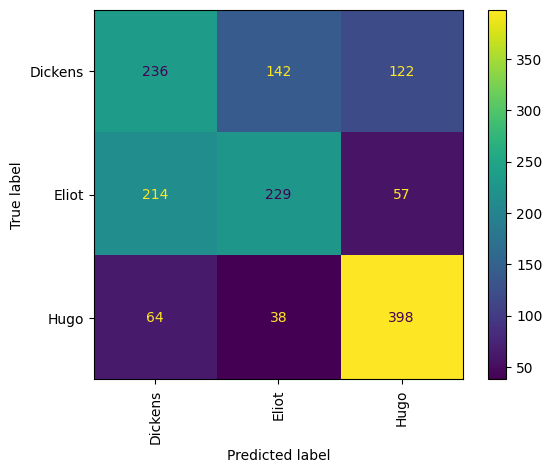

In [ ]:
# Somma
compute_filtered_embeddings_agg(all_documents, 2, pos_list = ['VERB', 'NOUN', 'ADV'])
x_test_5, y_test_5, model_5 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6125
Accuracy sul validation set: 0.5493333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.44      0.41      0.42       500
       Eliot       0.53      0.43      0.48       500
        Hugo       0.64      0.81      0.71       500

    accuracy                           0.55      1500
   macro avg       0.54      0.55      0.54      1500
weighted avg       0.54      0.55      0.54      1500

Accuracy del DummyClassifier: 0.32866666666666666


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


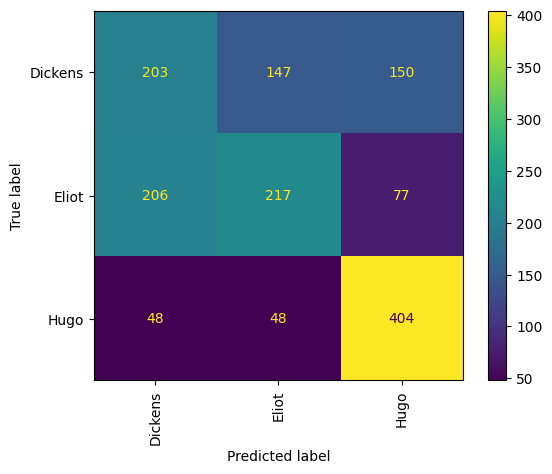

In [ ]:
# Max
compute_filtered_embeddings_agg(all_documents, 3, pos_list = ['VERB', 'NOUN', 'ADV'])
x_test_5, y_test_5, model_5 = validation_task_3(all_documents)

### 3) VERB, CONJJ e NOUN

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6841666666666666
Accuracy sul validation set: 0.6053333333333333
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.49      0.43      0.46       500
       Eliot       0.60      0.52      0.56       500
        Hugo       0.68      0.87      0.76       500

    accuracy                           0.61      1500
   macro avg       0.59      0.61      0.59      1500
weighted avg       0.59      0.61      0.59      1500

Accuracy del DummyClassifier: 0.334


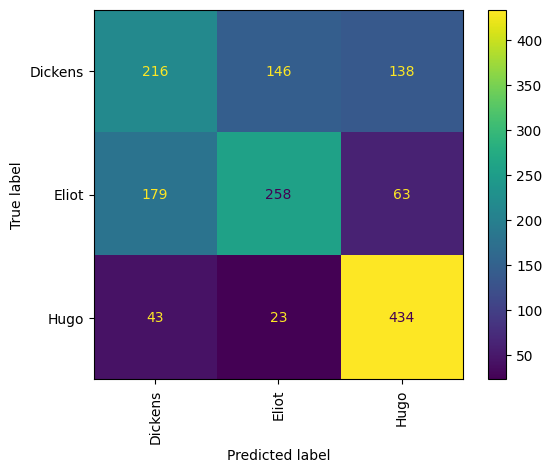

In [ ]:
# Media
compute_filtered_embeddings_agg(all_documents, 1, pos_list = ['VERB', 'CCONJ', 'NOUN'])
x_test_6, y_test_6, model_6 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6861111111111111
Accuracy sul validation set: 0.594
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.48      0.46      0.47       500
       Eliot       0.60      0.50      0.55       500
        Hugo       0.69      0.82      0.75       500

    accuracy                           0.59      1500
   macro avg       0.59      0.59      0.59      1500
weighted avg       0.59      0.59      0.59      1500

Accuracy del DummyClassifier: 0.3506666666666667


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


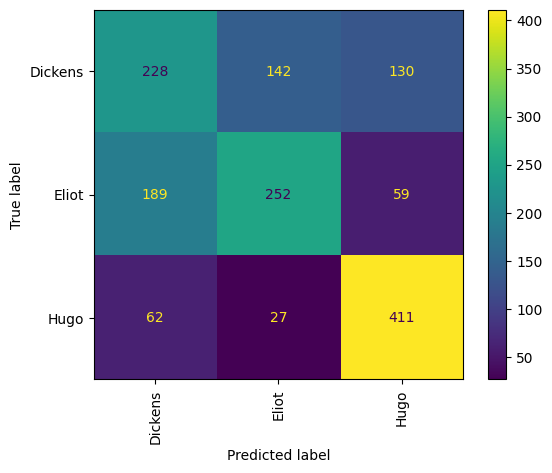

In [ ]:
# Somma
compute_filtered_embeddings_agg(all_documents, 2, pos_list = ['VERB', 'CCONJ', 'NOUN'])
x_test_7, y_test_7, model_7 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6158333333333335
Accuracy sul validation set: 0.5526666666666666
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.45      0.39      0.42       500
       Eliot       0.53      0.44      0.48       500
        Hugo       0.64      0.83      0.72       500

    accuracy                           0.55      1500
   macro avg       0.54      0.55      0.54      1500
weighted avg       0.54      0.55      0.54      1500

Accuracy del DummyClassifier: 0.328


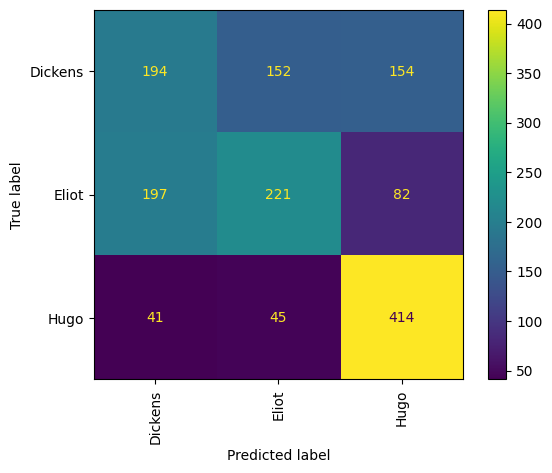

In [ ]:
# Max
compute_filtered_embeddings_agg(all_documents, 3, pos_list = ['VERB', 'CCONJ', 'NOUN'])
x_test_8, y_test_8, model_8 = validation_task_3(all_documents)

### NOUN, VERB e INTJ

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6755555555555556
Accuracy sul validation set: 0.592
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.47      0.41      0.44       500
       Eliot       0.58      0.49      0.54       500
        Hugo       0.68      0.87      0.76       500

    accuracy                           0.59      1500
   macro avg       0.58      0.59      0.58      1500
weighted avg       0.58      0.59      0.58      1500

Accuracy del DummyClassifier: 0.34


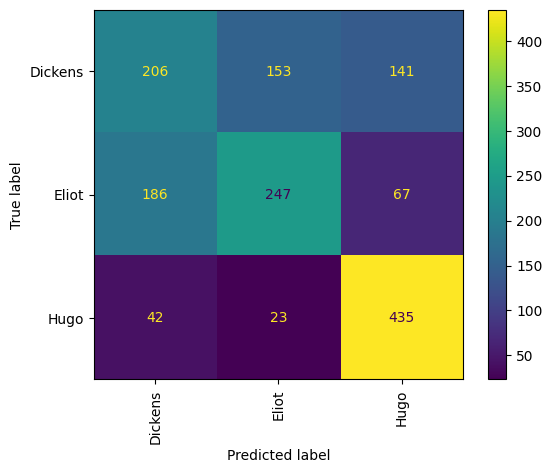

In [ ]:
# Media
compute_filtered_embeddings_agg(all_documents, 1, pos_list = ['VERB', 'INTJ', 'NOUN'])
x_test_9, y_test_9, model_9 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6783333333333335
Accuracy sul validation set: 0.59
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.47      0.46      0.46       500
       Eliot       0.58      0.47      0.52       500
        Hugo       0.70      0.85      0.76       500

    accuracy                           0.59      1500
   macro avg       0.58      0.59      0.58      1500
weighted avg       0.58      0.59      0.58      1500

Accuracy del DummyClassifier: 0.31666666666666665


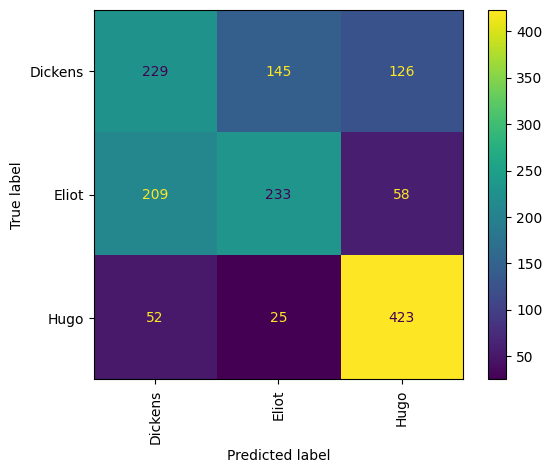

In [ ]:
# Somma
compute_filtered_embeddings_agg(all_documents, 2, pos_list = ['VERB', 'INTJ', 'NOUN'])
x_test_10, y_test_10, model_10 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.6094444444444445
Accuracy sul validation set: 0.5566666666666666
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.45      0.39      0.42       500
       Eliot       0.53      0.43      0.47       500
        Hugo       0.64      0.86      0.73       500

    accuracy                           0.56      1500
   macro avg       0.54      0.56      0.54      1500
weighted avg       0.54      0.56      0.54      1500

Accuracy del DummyClassifier: 0.344


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


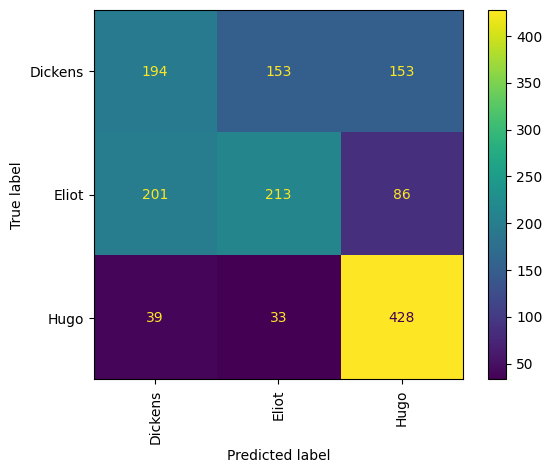

In [ ]:
# Max
compute_filtered_embeddings_agg(all_documents, 3, pos_list = ['VERB', 'INTJ', 'NOUN'])
x_test_11, y_test_11, model_11 = validation_task_3(all_documents)

### CCONJ, INTJ, ADV

Train has NaNs: False
Train has Infs: False
Train max value: 1.0
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear fa

0.5363888888888889
Accuracy sul validation set: 0.48
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.43      0.40      0.41       500
       Eliot       0.44      0.42      0.43       500
        Hugo       0.55      0.62      0.59       500

    accuracy                           0.48      1500
   macro avg       0.48      0.48      0.48      1500
weighted avg       0.48      0.48      0.48      1500

Accuracy del DummyClassifier: 0.3293333333333333


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


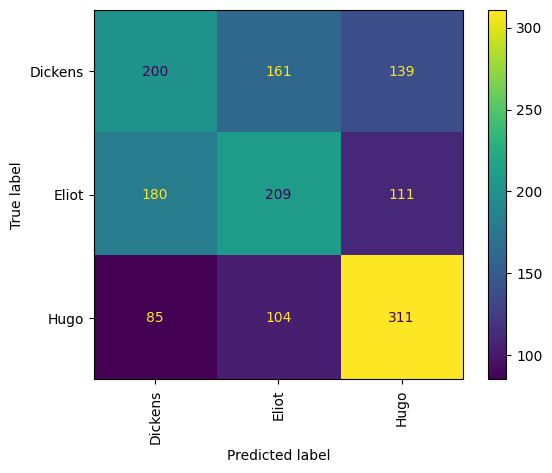

In [ ]:
# Media
compute_filtered_embeddings_agg(all_documents, 1, pos_list = ['CCONJ', 'INTJ', 'ADV'])
x_test_12, y_test_12, model_12 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/laviniarotellini/Desktop/Progetto_LINGCOMP2/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear fa

0.55
Accuracy sul validation set: 0.502
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.45      0.40      0.43       500
       Eliot       0.47      0.38      0.42       500
        Hugo       0.56      0.72      0.63       500

    accuracy                           0.50      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.49      0.50      0.49      1500

Accuracy del DummyClassifier: 0.31533333333333335


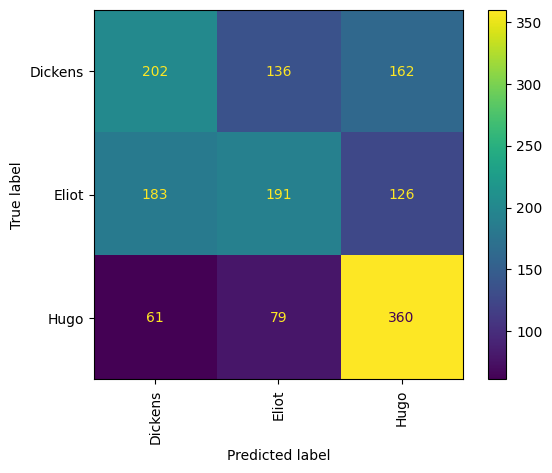

In [ ]:
# Somma
compute_filtered_embeddings_agg(all_documents, 2, pos_list = ['CCONJ', 'INTJ', 'ADV'])
x_test_13, y_test_13, model_13 = validation_task_3(all_documents)

Train has NaNs: False
Train has Infs: False
Train max value: 1.0000000000000002
Train min value: 0.0
Fitting 5 folds for each of 40 candidates, totalling 200 fits
0.5122222222222221
Accuracy sul validation set: 0.4746666666666667
Classification report sul validation set:               precision    recall  f1-score   support

     Dickens       0.41      0.38      0.39       500
       Eliot       0.45      0.41      0.43       500
        Hugo       0.55      0.64      0.59       500

    accuracy                           0.47      1500
   macro avg       0.47      0.47      0.47      1500
weighted avg       0.47      0.47      0.47      1500

Accuracy del DummyClassifier: 0.344


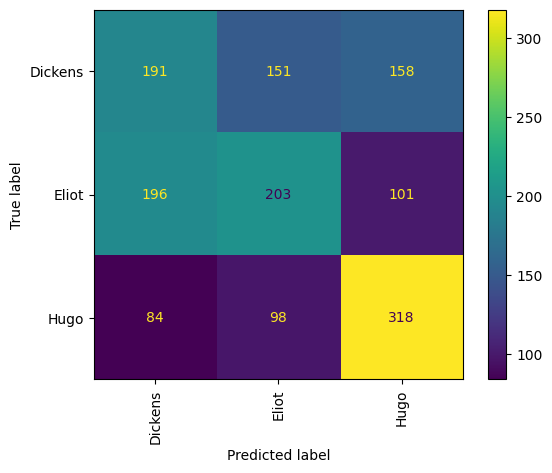

In [26]:
# Max
compute_filtered_embeddings_agg(all_documents, 3, pos_list = ['CCONJ', 'INTJ', 'ADV'])
x_test_14, y_test_14, model_14 = validation_task_3(all_documents)

## Fase di Testing con i Modelli Migliori

Le configurazioni migliori si sono rivelate essere la media e la somma degli embeddings di tutte le parole, per le quali procederemo con la fase di testing. 

Accuracy sul test set: 0.7354345749761223
Classification report sul test set:               precision    recall  f1-score   support

     Dickens       0.70      0.61      0.65       698
       Eliot       0.70      0.69      0.70       698
        Hugo       0.79      0.91      0.85       698

    accuracy                           0.74      2094
   macro avg       0.73      0.74      0.73      2094
weighted avg       0.73      0.74      0.73      2094



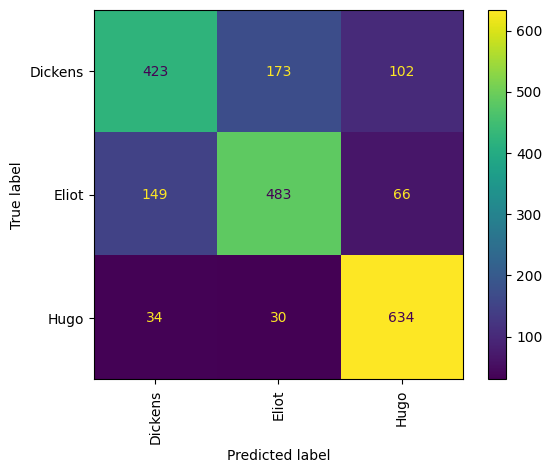

In [30]:
y_pred_mean = utils_svm.predict(model_mean_tot, x_test_mean_tot, y_test_mean_tot, split = 'test set')

Accuracy sul test set: 0.7368672397325693
Classification report sul test set:               precision    recall  f1-score   support

     Dickens       0.70      0.63      0.66       698
       Eliot       0.69      0.67      0.68       698
        Hugo       0.80      0.91      0.85       698

    accuracy                           0.74      2094
   macro avg       0.73      0.74      0.73      2094
weighted avg       0.73      0.74      0.73      2094



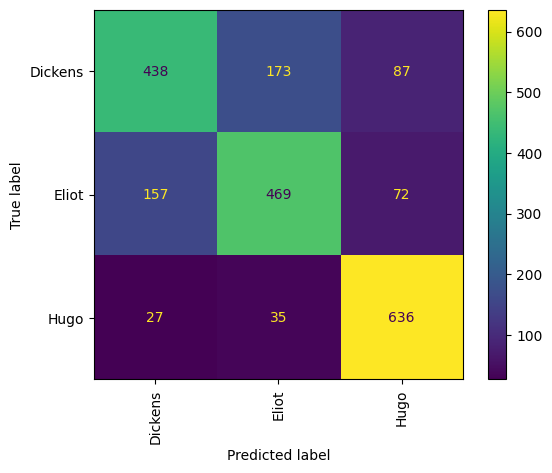

In [31]:
y_pred_sum = utils_svm.predict(model_sum_tot, x_test_sum_tot, y_test_sum_tot, split='test set')